# Complementarity Analysis

## tl;dr
Primary-sample correlation between talent and gap closure is 0.350; distinct definitions need not be statistically independent.

## Context & Methods
Core skills are four-player averages. Fill is the capped increase in the weakest below-average dimension when forming the five-player average.

### Key Assumptions
Regular-season PBP Stats aggregates; lagged profiles; observational comparisons. See [methodology](../docs/methodology_notes.md).

## Data
Run the cached pipeline and offline analysis before this notebook. No network requests are made here.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'data_pipeline.py').exists())
DATA = ROOT / 'data' / 'processed'
import sys
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
pd.set_option('display.max_columns', 12)


## Results

### Deficiencies by core

In [2]:
display(pd.read_csv(DATA/'deficiency_summary.csv'))

,weakest_skill,cores,mean_gap
0,creation,43,0.299203
1,interior,150,0.338326
2,playmaking,36,0.293614
3,rebounding,78,0.323369
4,spacing,123,0.390116


### Talent versus complementarity

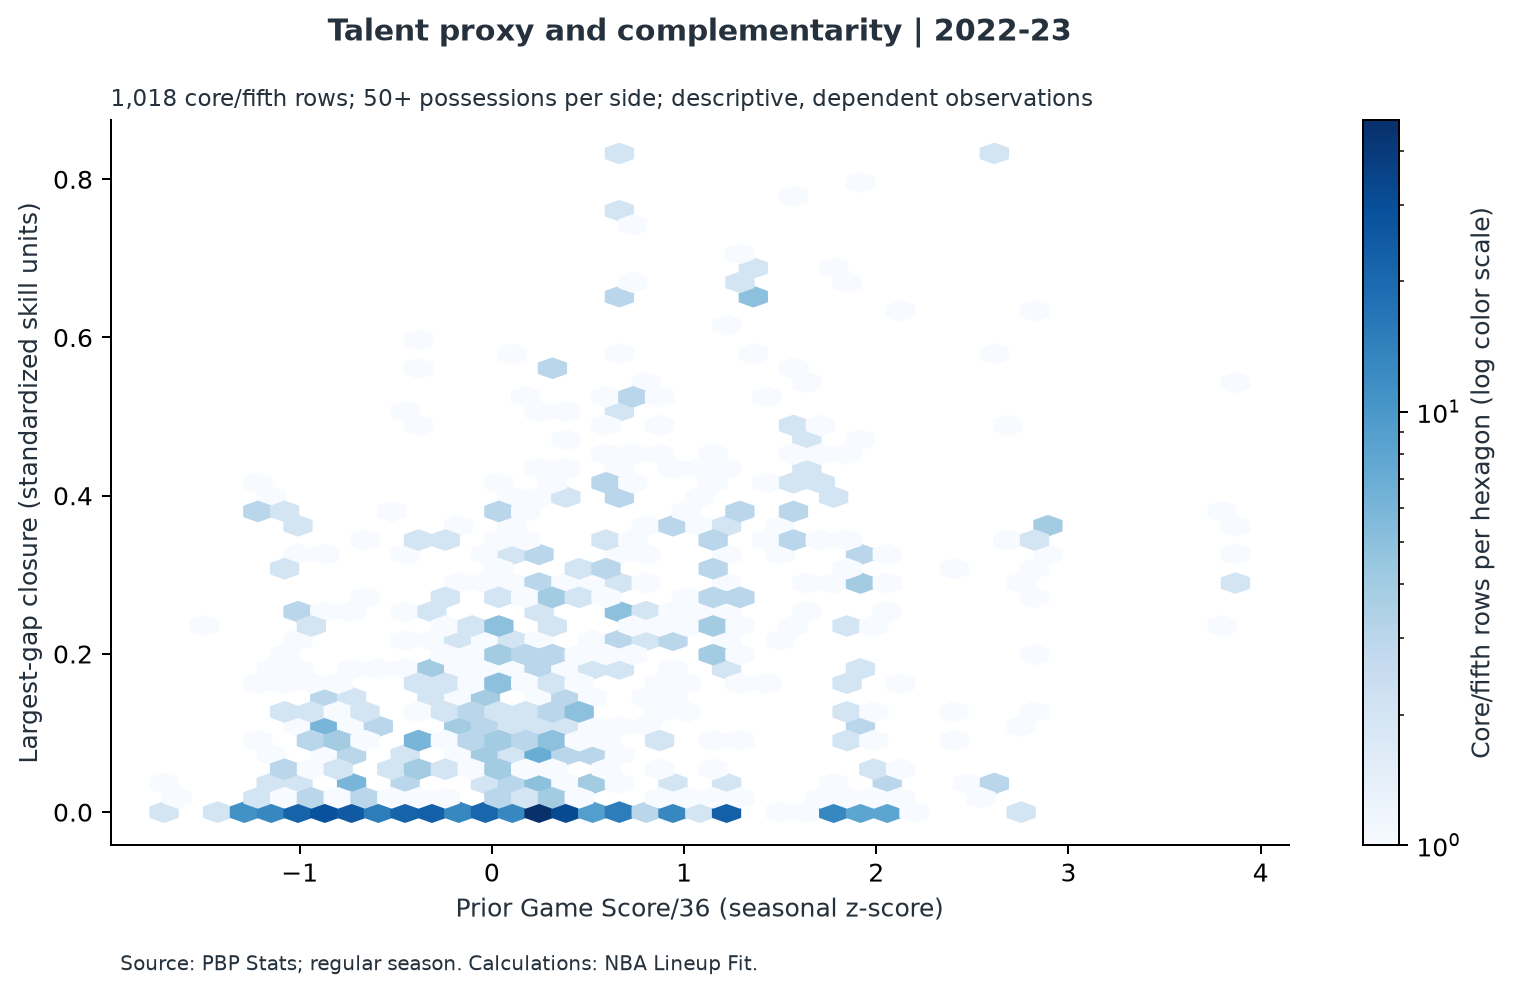

In [3]:
display(Image(filename=str(ROOT/'figures'/'talent_complementarity.png')))

### Example chosen without outcomes

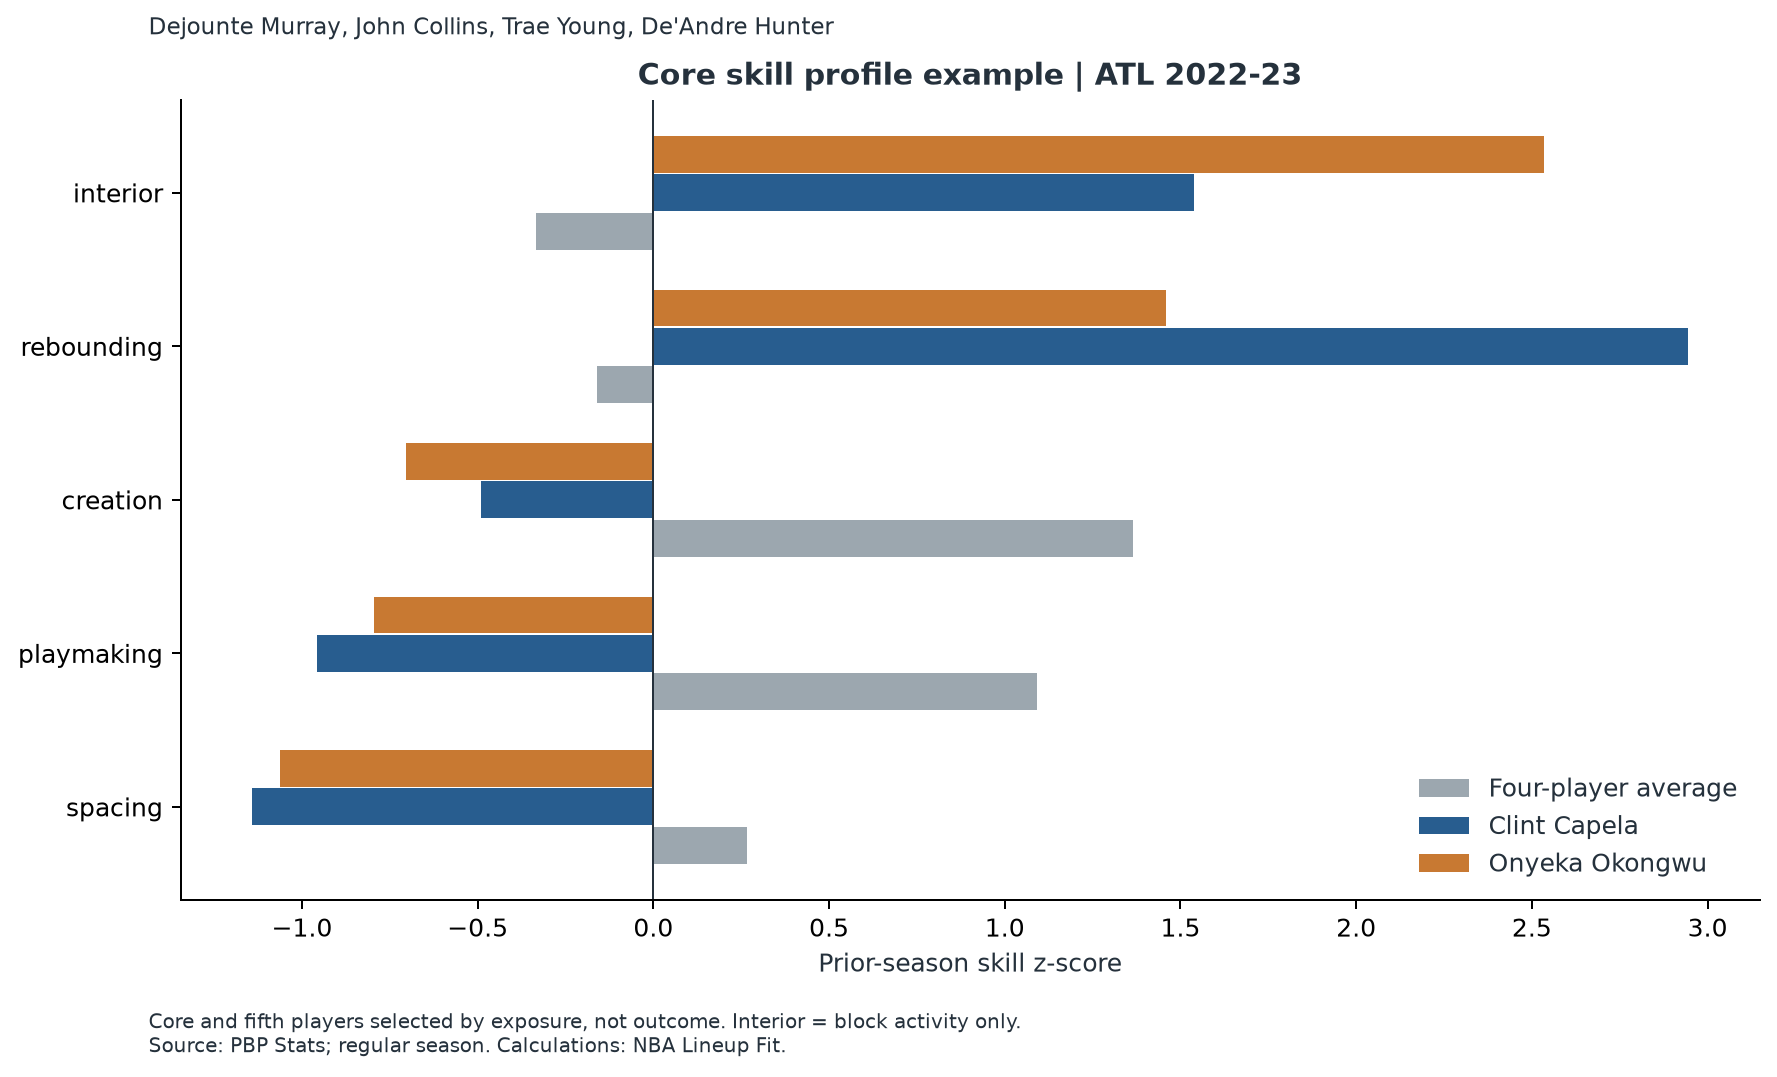

,season,team,core_id,fifth_id,fifth_id_name,possessions,net_rating,fifth_quality,weakest_skill,deficiency_gap,complementarity
0,2022-23,ATL,1627749-1628381-1629027-1629631,203991,Clint Capela,1553.0,5.280,1.147,interior,0.333,0.333
1,2022-23,ATL,1627749-1628381-1629027-1629631,1630168,Onyeka Okongwu,560.0,3.393,0.707,interior,0.333,0.333
2,2022-23,ATL,1627749-1628381-1629027-1629631,203992,Bogdan Bogdanovic,91.5,3.672,0.254,interior,0.333,0.000


In [4]:
display(Image(filename=str(ROOT/'figures'/'core_example.png')))
display(pd.read_csv(DATA/'core_example.csv').round(3))

### Sanity checks for the formula

In [5]:
from src.features import complementarity
core=np.array([[-1.,0,0,0,0],[1.,2,3,4,5]])
fifth=np.array([[1.,0,0,0,0],[9.,9,9,9,9]])
fill,_,_=complementarity(core,fifth)
assert np.allclose(fill,[.4,0])
print('A -1 core and +1 fifth closes 0.4 units; an all-positive core has zero measured gap.')

A -1 core and +1 fifth closes 0.4 units; an all-positive core has zero measured gap.


## Takeaways
This is an initial interpretable specification. Elite overall production does not ensure gap closure; a good role match does not establish a causal performance benefit.